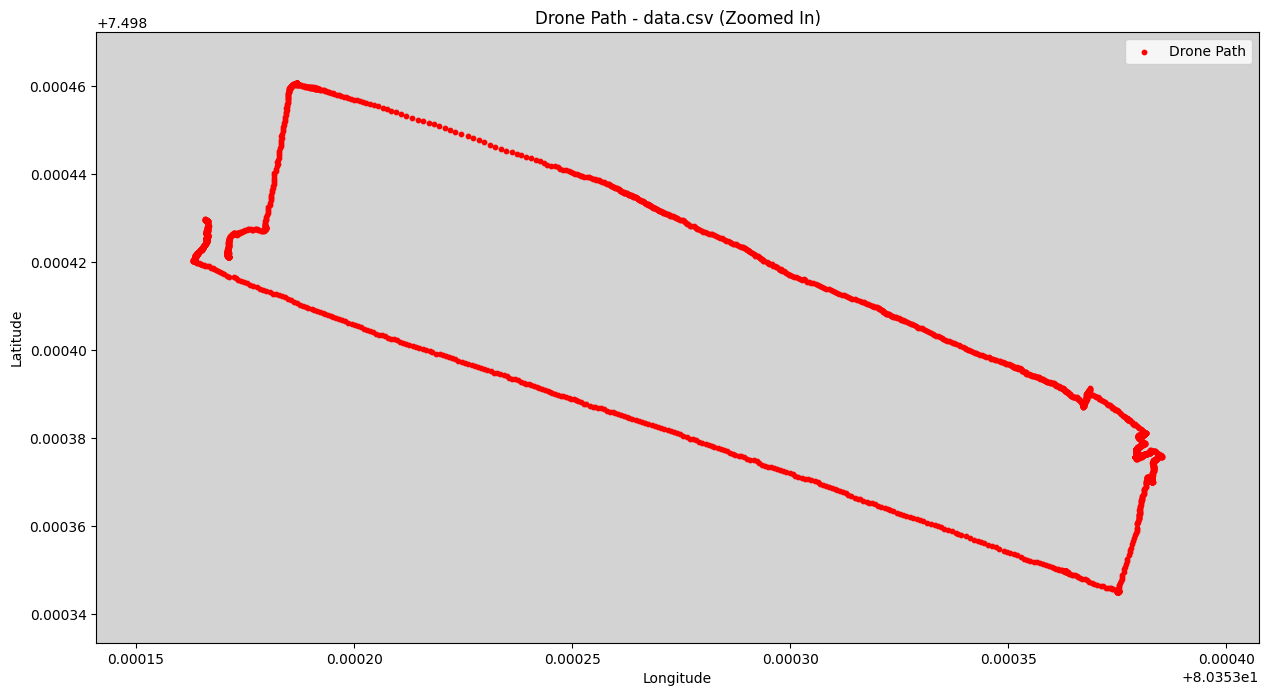

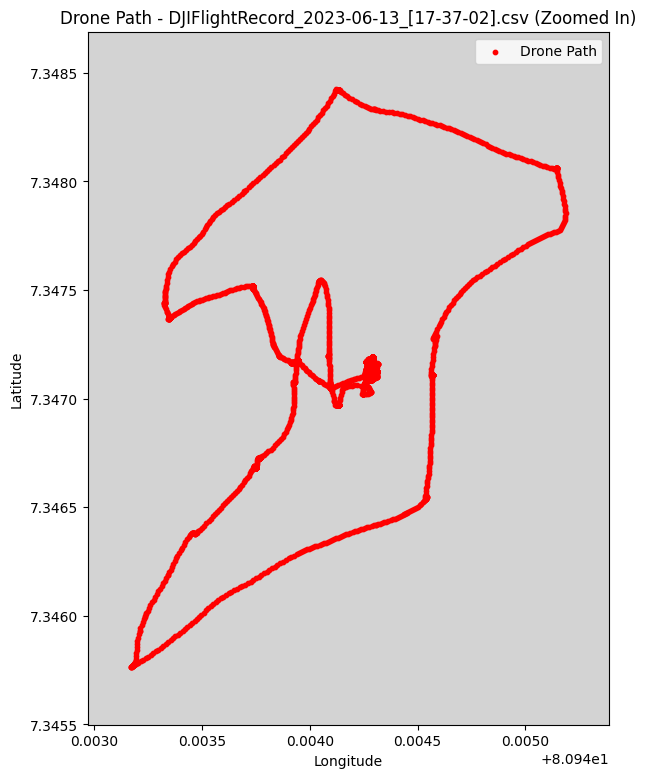

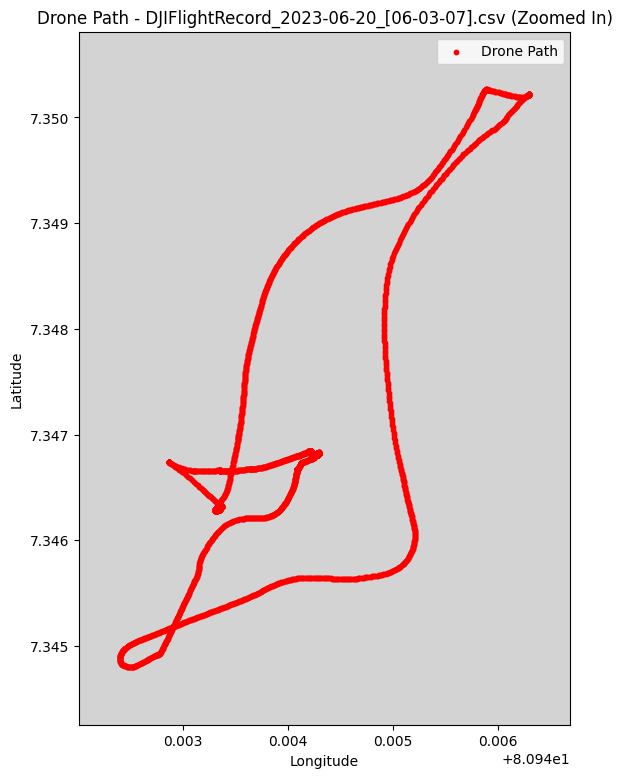

In [8]:
import os
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 9] 

# Get the current working directory
current_path = os.getcwd()

# Iterate through all CSV files in the current directory
for filename in os.listdir(current_path):
    if filename.endswith('.csv'):
        # Read CSV file into a DataFrame with explicit data types
        dtypes = {'OSD.longitude': 'float', 'OSD.latitude': 'float'}
        df = pd.read_csv(os.path.join(current_path, filename), dtype=dtypes)

        # Check if 'OSD.longitude' and 'OSD.latitude' columns exist
        if 'OSD.longitude' in df.columns and 'OSD.latitude' in df.columns:
            # Create a GeoDataFrame from the DataFrame with latitude and longitude
            geometry = [Point(xy) for xy in zip(df['OSD.longitude'], df['OSD.latitude'])]
            geo_df = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")  # Specify the CRS (Coordinate Reference System)

            # Create a new plot for each CSV file with increased figure size
            fig, ax = plt.subplots(figsize=(15, 9))  # Adjust the figsize parameter as needed

            # Get the bounding box of the drone path
            minx, miny, maxx, maxy = geo_df.geometry.total_bounds

            # Set the buffer for zooming (adjust as needed)
            buffer_percent = 0.1
            x_buffer = (maxx - minx) * buffer_percent
            y_buffer = (maxy - miny) * buffer_percent

            # Set the plot limits
            ax.set_xlim(minx - x_buffer, maxx + x_buffer)
            ax.set_ylim(miny - y_buffer, maxy + y_buffer)

            # Plot the world map
            world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
            world.plot(ax=ax, color='lightgrey')

            # Plot the drone path on top of the world map
            geo_df.plot(ax=ax, marker='o', color='red', markersize=10, label='Drone Path')

            # Customize the plot
            plt.title(f'Drone Path - {filename} (Zoomed In)')
            plt.xlabel('Longitude')
            plt.ylabel('Latitude')
            plt.legend()

            # Show the plot
            plt.show()



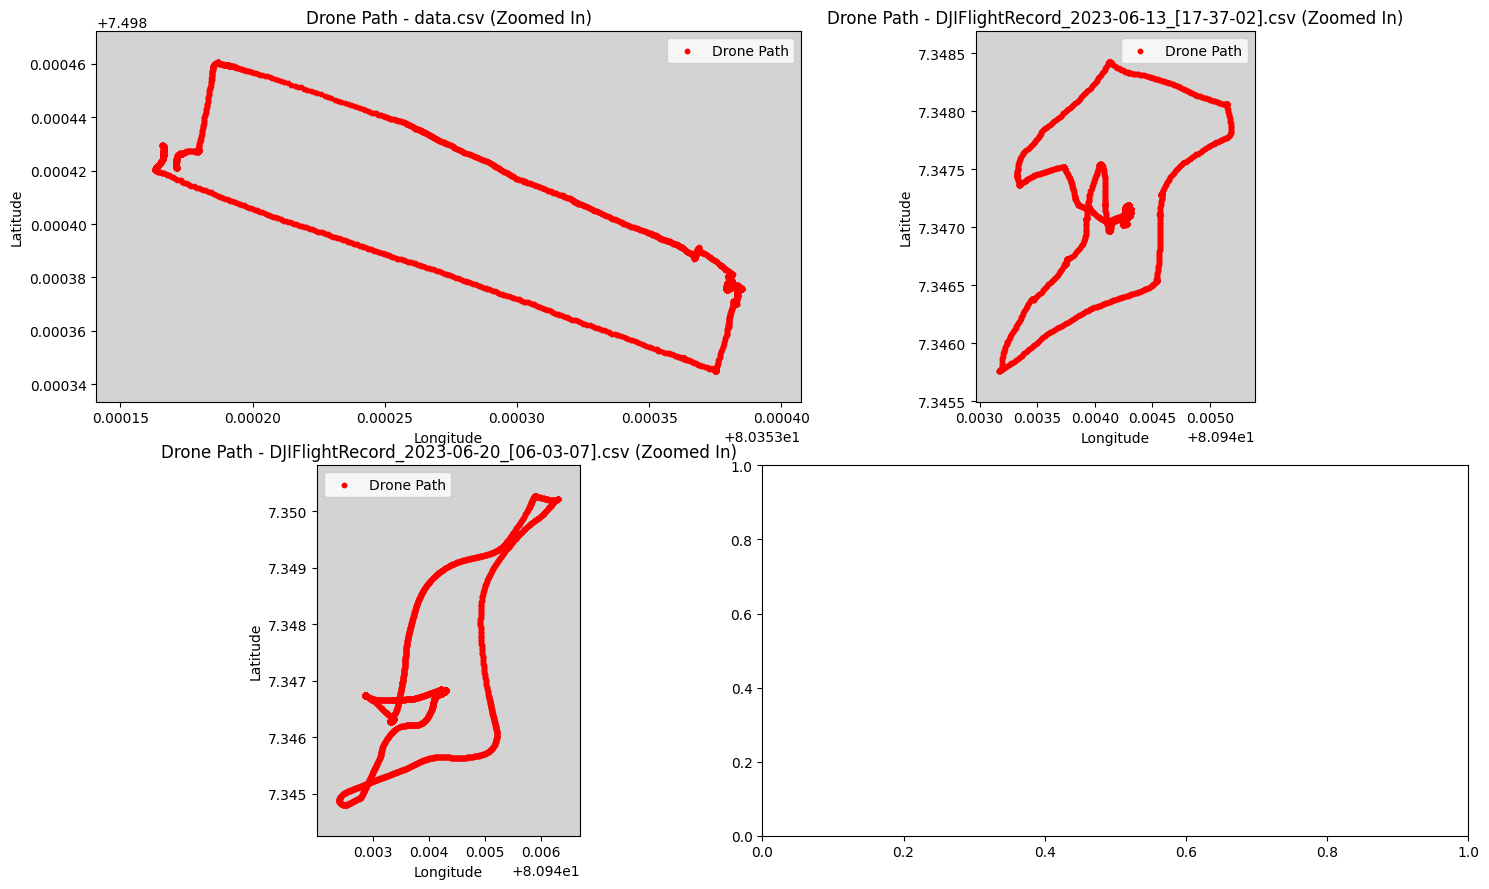

In [10]:
import os
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Set the figure size
plt.rcParams['figure.figsize'] = [10, 6]

# Get the current working directory
current_path = os.getcwd()

# Create a subplot with rows and columns for the CSV files
num_rows = 2  # Adjust the number of rows as needed
num_cols = 2  # Adjust the number of columns as needed

# Get the list of CSV files in the current directory
csv_files = [filename for filename in os.listdir(current_path) if filename.endswith('.csv')]

# Create subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 9))

# Flatten the subplot array for easy iteration
axs = axs.flatten()

# Iterate through CSV files and plot on subplots
for i, filename in enumerate(csv_files):
    # Read CSV file into a DataFrame with explicit data types
    dtypes = {'OSD.longitude': 'float', 'OSD.latitude': 'float'}
    df = pd.read_csv(os.path.join(current_path, filename), dtype=dtypes)

    # Check if 'OSD.longitude' and 'OSD.latitude' columns exist
    if 'OSD.longitude' in df.columns and 'OSD.latitude' in df.columns:
        # Create a GeoDataFrame from the DataFrame with latitude and longitude
        geometry = [Point(xy) for xy in zip(df['OSD.longitude'], df['OSD.latitude'])]
        geo_df = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")  # Specify the CRS (Coordinate Reference System)

        # Get the current subplot
        ax = axs[i]

        # Get the bounding box of the drone path
        minx, miny, maxx, maxy = geo_df.geometry.total_bounds

        # Set the buffer for zooming (adjust as needed)
        buffer_percent = 0.1
        x_buffer = (maxx - minx) * buffer_percent
        y_buffer = (maxy - miny) * buffer_percent

        # Set the plot limits
        ax.set_xlim(minx - x_buffer, maxx + x_buffer)
        ax.set_ylim(miny - y_buffer, maxy + y_buffer)

        # Plot the world map
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        world.plot(ax=ax, color='lightgrey')

        # Plot the drone path on top of the world map
        geo_df.plot(ax=ax, marker='o', color='red', markersize=10, label='Drone Path')

        # Customize the subplot
        ax.set_title(f'Drone Path - {filename} (Zoomed In)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.legend()

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plots
plt.show()


In [9]:
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")
